# Разработка системы интеллектуального ранжирования рекламных предложений на основе машинного обучения

Выпускная работа по курсу «Data Scientist». Автор: Андрей Васильев.

## Задача

Рекламный сервис показывает предложения партнёрских сетей на сайтах компании. В
витрине несколько мест, а предложений больше, поэтому система выбирает, что
показать и в каком порядке. Сейчас выбор делает жёсткое правило без машинного
обучения.

Работа проверяет, можно ли выбирать лучше. Ранжирование строится не по
вероятности клика, а по ожидаемому доходу показа:

**ожидаемый доход = P(клик) × P(конверсия при клике) × ожидаемая выплата**

Причина в том, что предложения сильно различаются по цене конверсии: сортировка
по кликам поднимает дешёвое предложение с высоким откликом и вытесняет дорогое,
которое приносит больше денег с того же показа.

## План работы

1. Загрузка и осмотр данных
2. Очистка выборки
3. Целевые переменные
4. Признаки
5. Разбиение на обучение и проверку
6. Базовые решения для сравнения
7. Модель клика
8. Модель конверсии
9. Ожидаемый доход и сравнение всех решений
10. Выводы и ограничения

## 1. Загрузка и осмотр данных

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 50)

DATA = Path.cwd().parent / "datasets"
files = sorted(DATA.glob("impressions-*.csv"))
print("файлы выгрузки:", [f.name for f in files])

файлы выгрузки: ['impressions-2026-07.csv', 'impressions-2026-08.csv']


Данные это выгрузка показов рекламы: одна строка равна одному показу одного
предложения одному посетителю.

При чтении задаю два параметра явно. Коды регионов читаю строкой, иначе `08`
превратится в 8 и ведущий ноль потеряется. И отключаю стандартный список пустых
значений, иначе код страны Намибии `NA` будет прочитан как пропуск.

In [2]:
date_cols = ["impression_at", "visit_started_at", "click_at", "conversion_at"]

df = pd.concat(
    [pd.read_csv(f, parse_dates=date_cols, dtype={"geo_region": "string"},
                 keep_default_na=False, na_values="") for f in files],
    ignore_index=True,
).sort_values("impression_at").reset_index(drop=True)

print(f"строк: {len(df):,}".replace(",", " "))
print(f"колонок: {df.shape[1]}")
print(f"период: {df['impression_at'].min():%d.%m.%Y} по {df['impression_at'].max():%d.%m.%Y}")
df.head()

строк: 3 021 546
колонок: 43
период: 01.07.2026 по 22.08.2026


,offer_impression_id,advertising_impression_id,impression_at,visitor_id,visit_id,visit_started_at,site_id,placement_id,position_id,advertising_id,advertising_type,source_id,campaign_id,page_url_id,landing_page_url_id,http_referrer_host,user_agent_id,device_type,os_name,browser_name,ip_id,geo_country,geo_region,bot_type,position_index,is_swap,preset_id,offer_id,partner_offer_id,partner_id,creative_id,partner_offer_payout_current,partner_offer_bonus_current,target_click,click_id,click_at,target_conversion,conversion_id,conversion_at,conversion_payout,conversion_bonus,conversion_revoked,conversion_origin
0,85422,80196.0,2026-07-01 00:00:08,NaN,NaN,NaT,31,83,6,57,banner,NaN,NaN,57835.0,NaN,NaN,8559.0,NaN,NaN,Chrome,53833.0,RU,<NA>,YandexRenderResourcesBot,0,NaN,29,27,30,7,32,0,0,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN
1,85423,80197.0,2026-07-01 00:00:32,157221.0,186057.0,2026-07-01 00:00:27,39,128,5,52,banner,1.0,45.0,207648.0,207648.0,NaN,4193.0,smartphone,Android,Yandex Browser,82837.0,RU,KHA,NaN,0,NaN,33,27,30,7,36,0,0,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN
2,85424,80198.0,2026-07-01 00:00:40,64042.0,186059.0,2026-07-01 00:00:39,28,77,5,52,banner,1.0,5.0,207650.0,207650.0,NaN,8314.0,smartphone,Android,Yandex Browser,61858.0,RU,SVE,NaN,0,NaN,33,27,30,7,36,0,0,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN
3,85425,80199.0,2026-07-01 00:00:51,157222.0,186060.0,2026-07-01 00:00:50,31,130,5,52,banner,1.0,62.0,207651.0,207651.0,NaN,119.0,smartphone,Android,Chrome Mobile,102364.0,RU,<NA>,NaN,0,NaN,31,17,31,2,34,40,10,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN
4,85426,80200.0,2026-07-01 00:00:53,64042.0,186059.0,2026-07-01 00:00:39,28,84,6,57,banner,1.0,5.0,207652.0,207650.0,NaN,8314.0,smartphone,Android,Yandex Browser,61858.0,RU,SVE,NaN,0,NaN,29,27,30,7,32,0,0,0,NaN,NaT,0,NaN,NaT,NaN,NaN,NaN,NaN


In [3]:
print("Основные показатели выгрузки")
print(f"показов:   {len(df):,}".replace(",", " "))
print(f"кликов:    {df['target_click'].sum():,} (CTR {df['target_click'].mean():.2%})".replace(",", " "))
print(f"конверсий: {df['target_conversion'].sum():,}".replace(",", " "))
print(f"конверсия от кликов: {df.loc[df['target_click'] == 1, 'target_conversion'].mean():.1%}")
print(f"посетителей: {df['visitor_id'].nunique():,}".replace(",", " "))
print(f"предложений: {df['offer_id'].nunique()}, связок с партнёрами: {df['partner_offer_id'].nunique()}")

Основные показатели выгрузки
показов:   3 021 546
кликов:    207 188 (CTR 6.86%)
конверсий: 79 671
конверсия от кликов: 38.5%
посетителей: 438 793
предложений: 24, связок с партнёрами: 30


Смотрю, как показы распределены по дням и меняется ли набор предложений.

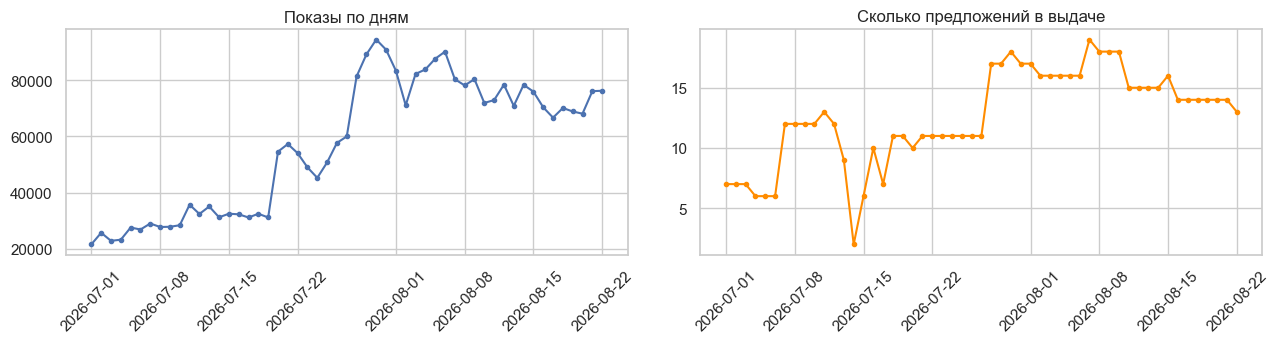

In [4]:
daily = df.groupby(df["impression_at"].dt.date).agg(
    shows=("target_click", "size"),
    offers=("offer_id", "nunique"),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.6))
ax1.plot(daily.index, daily["shows"], marker="o", markersize=3)
ax1.set_title("Показы по дням")
ax2.plot(daily.index, daily["offers"], marker="o", markersize=3, color="darkorange")
ax2.set_title("Сколько предложений в выдаче")
for ax in (ax1, ax2):
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Видно две вещи, которые определяют всю дальнейшую работу.

Трафик за период вырос в несколько раз: сервис новый и набирает объём. Значит
ранние и поздние дни это разные условия, и проверять модель случайной выборкой
строк нельзя, иначе она будет учиться на будущем.

Набор предложений тоже меняется: часть появляется и исчезает в середине периода.
Значит модель должна уметь оценить предложение, которого раньше не видела.

Проверяю главное предположение работы: что предложения различаются по цене
конверсии. Если бы все стоили одинаково, ранжировать по деньгам не имело бы
смысла.

In [5]:
money = df[df["target_conversion"] == 1].groupby("partner_offer_id").agg(
    conversions=("target_conversion", "size"),
    median_payout=("conversion_payout", "median"),
    turnover=("conversion_payout", "sum"),
).sort_values("turnover", ascending=False)
money["turnover_share"] = (money["turnover"] / money["turnover"].sum() * 100).round(1)
display(money.head(8))

print(f"медианная выплата: от {money['median_payout'].min():.0f} до {money['median_payout'].max():.0f} руб")

,conversions,median_payout,turnover,turnover_share
partner_offer_id,,,,
36,4990,750.0,3742500.0,34.4
30,5786,300.0,1735800.0,15.9
31,41881,40.0,1675240.0,15.4
38,3336,140.0,537379.0,4.9
37,976,453.0,442128.0,4.1
26,616,630.0,401980.0,3.7
21,2456,140.0,324176.0,3.0
46,3427,91.0,311857.0,2.9


медианная выплата: от 40 до 2550 руб


Разброс в десятки раз, предположение подтвердилось.

Отдельно проверяю цену из справочника: она известна на момент показа, и было бы
удобно использовать её. Оказывается, нельзя.

In [6]:
nominal = df.groupby("partner_offer_id")["partner_offer_payout_current"].first()
zero_links = nominal[nominal == 0].index
print(f"связок со ставкой 0 в справочнике: {len(zero_links)} из {len(nominal)}")
print(f"на них приходится {df['partner_offer_id'].isin(zero_links).mean():.1%} показов")
print(f"при этом реальных выплат по ним: {df[df['partner_offer_id'].isin(zero_links)]['conversion_payout'].sum():,.0f} руб".replace(",", " "))

связок со ставкой 0 в справочнике: 26 из 30
на них приходится 72.3% показов


при этом реальных выплат по ним: 5 249 304 руб


У большинства связок в справочнике стоит ноль, хотя деньги по ним реально
приходят: в колонке лежит номинал на момент выгрузки, а фактическая сумма
приходит от партнёра вместе с уведомлением о конверсии. Поэтому деньгами считаю
фактическую выплату, а справочную ставку оставляю просто признаком.

## 2. Очистка выборки

Убираю три группы строк. Каждая из них описывает не поведение посетителя, а
что-то другое.

In [7]:
before = len(df)

# 1. Роботы поисковых систем: у них своя колонка, заполнено значит бот
is_bot = df["bot_type"].notna()
print(f"роботы: CTR {df.loc[is_bot, 'target_click'].mean():.1%} против "
      f"{df.loc[~is_bot, 'target_click'].mean():.1%} у людей, "
      f"конверсий {df.loc[is_bot, 'target_conversion'].sum()}")

# 2. Подменённые карточки: после клика карточка скрывается, а снизу подставляется
# новая. Такой показ возникает только потому, что клик уже случился. Определяю по
# времени: карточки первого показа появляются вместе, подмена отстаёт.
first_in_block = df.groupby("advertising_impression_id")["impression_at"].transform("min")
lag = (df["impression_at"] - first_in_block).dt.total_seconds()
is_swap = (lag > 1) | df["advertising_impression_id"].isna()

# 3. Партнёр, который платил за клик: у него конверсия создавалась самим переходом,
# предсказывать там нечего. Он перешёл на обычную схему, дату перехода беру из данных.
cpc = df["conversion_origin"] == "click"
if cpc.any():
    cpc_partner = df.loc[cpc, "partner_id"].mode()[0]
    switch_date = df.loc[cpc, "impression_at"].max()
    was_cpc = (df["partner_id"] == cpc_partner) & (df["impression_at"] <= switch_date)
    print(f"партнёр {cpc_partner} платил за клик по {switch_date:%d.%m.%Y}")
else:
    was_cpc = pd.Series(False, index=df.index)

df = df[~(is_bot | is_swap | was_cpc)].copy()

print(f"\nубрано роботов: {is_bot.sum():,}".replace(",", " "))
print(f"убрано подмен: {is_swap.sum():,}".replace(",", " "))
print(f"убрано по оплате за клик: {was_cpc.sum():,}".replace(",", " "))
print(f"осталось: {len(df):,} из {before:,} ({len(df) / before:.1%})".replace(",", " "))

роботы: CTR 19.4% против 6.3% у людей, конверсий 480


партнёр 4 платил за клик по 15.08.2026



убрано роботов: 132 935
убрано подмен: 92 959
убрано по оплате за клик: 141 094
осталось: 2 655 171 из 3 021 546 (87.9%)


## 3. Целевые переменные

Задача разбивается на две части, потому что конверсия возможна только после
клика. Первая модель предсказывает клик и учится на всех показах. Вторая
предсказывает конверсию и учится только на кликах: если учить её на всех показах,
она заново выучит вероятность клика, которую уже знает первая.

Дополнительно убираю из обучения второй модели связки, по которым кликов много, а
конверсий нет ни одной. Почти всегда это значит, что партнёр не присылает
уведомления о покупках, а не то, что предложение плохое.

In [8]:
clicks = df[df["target_click"] == 1]
by_link = clicks.groupby("partner_offer_id").agg(
    clicks=("target_click", "size"),
    conversions=("target_conversion", "sum"),
)
silent = by_link[(by_link["conversions"] == 0) & (by_link["clicks"] >= 100)].index
display(by_link.loc[silent])

df["revenue"] = np.where(df["target_conversion"] == 1,
                         df["conversion_payout"] + df["conversion_bonus"], 0)
df["stage2"] = (df["target_click"] == 1) & (~df["partner_offer_id"].isin(silent))

print(f"первая ступень: {len(df):,} показов, {df['target_click'].sum():,} кликов".replace(",", " "))
print(f"вторая ступень: {df['stage2'].sum():,} кликов, ".replace(",", " ")
      + f"{df.loc[df['stage2'], 'target_conversion'].sum():,} конверсий".replace(",", " "))
print(f"доход за период: {df['revenue'].sum():,.0f} руб".replace(",", " "))

,clicks,conversions
partner_offer_id,,
15,2091,0


первая ступень: 2 655 171 показов  168 323 кликов
вторая ступень: 166 232 кликов  70 151 конверсий
доход за период: 10 665 509 руб


## 4. Признаки

Признаком может быть только то, что сервис знает **до** показа карточки. Всё, что
становится известно после (время клика, данные конверсии), в модель не идёт.

По этой же причине не использую позицию карточки в витрине и креатив: их выбирает
та самая система, которую мы заменяем, то есть в момент выбора предложения они
ещё не определены.

Признаки делю на четыре группы.

In [9]:
# Группа 1: время показа
df["hour"] = df["impression_at"].dt.hour
df["weekday"] = df["impression_at"].dt.dayofweek
df["weekend"] = (df["weekday"] >= 5).astype(int)
df["visit_depth"] = (df["impression_at"] - df["visit_started_at"]).dt.total_seconds()

# Группа 2: история посетителя, считается по прошлым показам
df["visitor_shows"] = df.groupby("visitor_id").cumcount()
df["visitor_clicks"] = df.groupby("visitor_id")["target_click"].cumsum() - df["target_click"]
df["visitor_offer_shows"] = df.groupby(["visitor_id", "offer_id"]).cumcount()
df["since_last_show"] = df.groupby("visitor_id")["impression_at"].diff().dt.total_seconds()

# Группа 3: насколько редкие у показа страница и устройство
for col, name in [("page_url_id", "page"), ("ip_id", "ip"), ("user_agent_id", "ua")]:
    df[f"{name}_count"] = df.groupby(col).cumcount()

print("признаков времени и истории готово")

признаков времени и истории готово


Важная деталь про историю посетителя. Карточки одного показа витрины идут в
данных подряд, поэтому счётчик внутри витрины растёт от карточки к карточке и
фактически показывает номер места. Но в момент выбора места ещё не назначены и
история у всех кандидатов одинаковая.

Поэтому всем карточкам одной витрины ставлю одно значение: то, которое было до
её показа.

In [10]:
counters = ["visit_depth", "visitor_shows", "visitor_clicks", "since_last_show",
            "page_count", "ip_count", "ua_count"]

for col in counters:
    df[col] = df.groupby("advertising_impression_id")[col].transform("first")

# Длинный хвост сжимаю логарифмом: разница между первым и десятым показом важна,
# между тысячным и тысяча первым уже нет
for col in ["visitor_shows", "visitor_clicks", "visitor_offer_shows",
            "page_count", "ip_count", "ua_count"]:
    df[col] = np.log1p(df[col])

df[counters + ["visitor_offer_shows"]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
visit_depth,2655171.0,149.85,331.44,-1.0,5.00,27.00,147.00,12258.00
visitor_shows,2655171.0,1.26,0.96,0.0,0.69,1.10,1.79,7.19
visitor_clicks,2655171.0,0.16,0.37,0.0,0.00,0.00,0.00,4.53
since_last_show,2235313.0,17439.04,134066.68,0.0,1.00,17.00,149.00,4514716.00
page_count,2655171.0,0.51,1.44,0.0,0.00,0.00,0.00,9.03
ip_count,2655171.0,1.94,1.45,0.0,1.10,1.61,2.71,10.30
ua_count,2655171.0,7.32,3.77,0.0,3.97,7.64,10.89,12.94
visitor_offer_shows,2655171.0,0.29,0.49,0.0,0.00,0.00,0.69,5.10


Четвёртая группа это репутация самого предложения: как часто по нему кликали
раньше, как часто после клика покупали и сколько в среднем платили.

Всё считается только по прошлым показам. И ещё оценка сглаживается: если
предложение показали три раза и один раз кликнули, его отклик формально 33
процента, что нелепо. Поэтому чем меньше накоплено показов, тем ближе оценка к
среднему уровню по всем данным.

In [11]:
SMOOTH = 100
mean_ctr = df["target_click"].mean()
mean_cr = df.loc[df["target_click"] == 1, "target_conversion"].mean()

for key, name in [("offer_id", "offer"), ("partner_offer_id", "link"), ("partner_id", "partner")]:
    shows_before = df.groupby(key).cumcount()
    clicks_before = df.groupby(key)["target_click"].cumsum() - df["target_click"]
    df[f"ctr_{name}"] = (clicks_before + SMOOTH * mean_ctr) / (shows_before + SMOOTH)

    conv_before = df.groupby(key)["target_conversion"].cumsum() - df["target_conversion"]
    df[f"cr_{name}"] = (conv_before + SMOOTH * mean_cr) / (clicks_before + SMOOTH)

# Ожидаемая выплата: средняя по прошлым конверсиям связки. Крупные выплаты обрезаю
# по верхнему процентилю, иначе одна редкая сумма задирает оценку
cap = df.loc[df["target_conversion"] == 1, "revenue"].quantile(0.99)
revenue_capped = df["revenue"].clip(upper=cap)
revenue_before = revenue_capped.groupby(df["partner_offer_id"]).cumsum() - revenue_capped
conv_before = df.groupby("partner_offer_id")["target_conversion"].cumsum() - df["target_conversion"]
mean_payout = df.loc[df["target_conversion"] == 1, "revenue"].mean()
df["payout_link"] = (revenue_before + SMOOTH * mean_payout) / (conv_before + SMOOTH)
df["payout_nominal"] = df["partner_offer_payout_current"]

df[["ctr_offer", "ctr_link", "cr_link", "payout_link"]].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
ctr_offer,2655171.0,0.065,0.041,0.010,0.051,0.066,0.077,0.291
ctr_link,2655171.0,0.064,0.041,0.010,0.033,0.064,0.081,0.291
cr_link,2655171.0,0.397,0.328,0.019,0.126,0.219,0.817,0.940
payout_link,2655171.0,210.609,152.351,50.258,84.736,180.468,294.917,738.243


In [12]:
NUM_COLS = ["hour", "weekday", "weekend", "visit_depth",
            "visitor_shows", "visitor_clicks", "visitor_offer_shows", "since_last_show",
            "page_count", "ip_count", "ua_count",
            "ctr_offer", "ctr_link", "ctr_partner", "cr_link", "cr_partner",
            "payout_link", "payout_nominal"]

CAT_COLS = ["site_id", "placement_id", "position_id", "advertising_id", "advertising_type",
            "source_id", "campaign_id", "device_type", "os_name", "browser_name",
            "geo_country", "geo_region", "preset_id", "offer_id", "partner_offer_id", "partner_id"]

for col in CAT_COLS:
    df[col] = df[col].astype(str)

FEATURES = NUM_COLS + CAT_COLS
print(f"числовых признаков: {len(NUM_COLS)}, категориальных: {len(CAT_COLS)}")
print("категории оставляю как есть: CatBoost умеет работать с ними напрямую")

# Сохраняю подготовленную таблицу, чтобы второй ноутбук не повторял всю подготовку
df.to_parquet(Path.cwd().parent / "cache" / "prepared.parquet", index=False)

числовых признаков: 18, категориальных: 16
категории оставляю как есть: CatBoost умеет работать с ними напрямую


## 5. Разбиение на обучение и проверку

Делю строго по времени: последние две недели откладываю на проверку, остальное
идёт в обучение. Случайное разбиение здесь запрещено, потому что данные растянуты
во времени и сервис за период менялся: перемешав строки, модель училась бы на
будущем и показала бы результат, который в реальной работе не повторится.

In [13]:
border = df["impression_at"].max().normalize() - pd.Timedelta(days=13)
train = df[df["impression_at"] < border]
test = df[df["impression_at"] >= border]

print(f"граница: {border:%d.%m.%Y}")
print(f"обучение: {len(train):,} показов, {len(train) / len(df):.0%}".replace(",", " "))
print(f"проверка: {len(test):,} показов, {len(test) / len(df):.0%}".replace(",", " "))
print(f"кликов в проверке: {test['target_click'].sum():,}".replace(",", " "))
print(f"конверсий в проверке: {test['target_conversion'].sum():,}".replace(",", " "))

new_offers = set(test["offer_id"]) - set(train["offer_id"])
print(f"предложений, которых не было в обучении: {len(new_offers)}")

граница: 09.08.2026
обучение: 1 736 724 показов  65%
проверка: 918 447 показов  35%
кликов в проверке: 55 654
конверсий в проверке: 21 669
предложений, которых не было в обучении: 3


## 6. Базовые решения для сравнения

Без базы сравнения метрика модели ничего не значит. Беру четыре простых правила
сортировки предложений:

1. случайный порядок, нижняя граница;
2. исторический CTR предложения, то есть популярность;
3. цена из справочника, проверка «а не решается ли задача бизнес-правилом»;
4. ожидаемый доход, посчитанный из накопленной статистики без всякого обучения.

Действующий алгоритм сервиса в базы не входит, и это важная оговорка. Он
детерминированный: кандидат либо показывается, либо нет, вероятности между ними
нет. Оценить по логам, что было бы при другом выборе, в такой ситуации
математически невозможно, для этого нужен A/B-тест.

In [14]:
np.random.seed(42)
baselines = {
    "случайный порядок": np.random.rand(len(test)),
    "популярность (CTR оффера)": test["ctr_offer"].to_numpy(),
    "цена из справочника": test["payout_nominal"].to_numpy(),
    "доход по статистике": (test["ctr_link"] * test["cr_link"] * test["payout_link"]).to_numpy(),
}

result = pd.DataFrame([
    {"решение": name,
     "ROC-AUC": roc_auc_score(test["target_click"], score),
     "PR-AUC": average_precision_score(test["target_click"], score)}
    for name, score in baselines.items()
]).set_index("решение")
display(result.round(4))

,ROC-AUC,PR-AUC
решение,,
случайный порядок,0.5027,0.0611
популярность (CTR оффера),0.6588,0.1279
цена из справочника,0.5977,0.1033
доход по статистике,0.6628,0.1293


## 7. Модель клика

Первая ступень. Обучаю CatBoost на всех показах обучающего периода.

Веса классов не использую специально. Они завышают предсказанные вероятности, а
мне вероятность нужна настоящая: её потом умножают на вероятность конверсии и на
деньги.

Параметры (глубина и скорость обучения) подобраны кросс-валидацией по времени,
расчёт вынесен во второй ноутбук.

In [15]:
click_model = CatBoostClassifier(depth=6, learning_rate=0.1, iterations=318,
                                 random_seed=42, verbose=100)
click_model.fit(Pool(train[FEATURES], train["target_click"], cat_features=CAT_COLS))

p_click = click_model.predict_proba(test[FEATURES])[:, 1]
print(f"\nROC-AUC: {roc_auc_score(test['target_click'], p_click):.4f}")
print(f"PR-AUC:  {average_precision_score(test['target_click'], p_click):.4f}")

0:	learn: 0.5789163	total: 803ms	remaining: 4m 14s


100:	learn: 0.2155663	total: 1m 5s	remaining: 2m 21s


200:	learn: 0.2142176	total: 2m 12s	remaining: 1m 17s


300:	learn: 0.2133074	total: 3m 22s	remaining: 11.4s


317:	learn: 0.2131749	total: 3m 32s	remaining: 0us



ROC-AUC: 0.7538
PR-AUC:  0.1923


Модель хорошо расставляет показы по порядку, но предсказанные вероятности
занижены: она говорит «три процента» там, где на самом деле кликают чаще. Для
сортировки это неважно, а для нашей формулы важно, потому что вероятности
перемножаются.

Поправку настраиваю на последней неделе обучающего периода, отдельной моделью,
которая эту неделю не видела. Иначе поправка подстроится под уже известные
ответы.

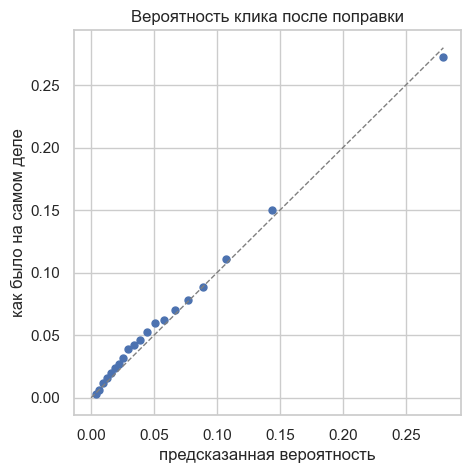

средняя предсказанная вероятность: 0.0567
фактическая доля кликов:           0.0606


In [16]:
edge = train["impression_at"].max().normalize() - pd.Timedelta(days=6)
fit_part, calib_part = train[train["impression_at"] < edge], train[train["impression_at"] >= edge]

helper = CatBoostClassifier(depth=6, learning_rate=0.1, iterations=318,
                            random_seed=42, verbose=False)
helper.fit(Pool(fit_part[FEATURES], fit_part["target_click"], cat_features=CAT_COLS))
p_calib = helper.predict_proba(calib_part[FEATURES])[:, 1]


def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)


click_calib = LogisticRegression().fit(logit(p_calib), calib_part["target_click"])
p_click = click_calib.predict_proba(logit(p_click))[:, 1]

bins = pd.qcut(p_click, 20, duplicates="drop")
curve = pd.DataFrame({"предсказано": p_click, "факт": test["target_click"].to_numpy()}).groupby(bins).mean()

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, curve.max().max()], [0, curve.max().max()], "--", color="grey", linewidth=1)
ax.scatter(curve["предсказано"], curve["факт"], s=25)
ax.set_xlabel("предсказанная вероятность")
ax.set_ylabel("как было на самом деле")
ax.set_title("Вероятность клика после поправки")
plt.show()

print(f"средняя предсказанная вероятность: {p_click.mean():.4f}")
print(f"фактическая доля кликов:           {test['target_click'].mean():.4f}")

## 8. Модель конверсии

Вторая ступень: учится только на кликах. Признаки те же самые, потому что оценка
делается в момент показа, когда клика ещё не было.

In [17]:
train2 = train[train["stage2"]]
test2 = test[test["stage2"]]

conv_model = CatBoostClassifier(depth=8, learning_rate=0.05, iterations=205,
                                random_seed=42, verbose=100)
conv_model.fit(Pool(train2[FEATURES], train2["target_conversion"], cat_features=CAT_COLS))

p_conv_test = conv_model.predict_proba(test2[FEATURES])[:, 1]
print(f"\nROC-AUC: {roc_auc_score(test2['target_conversion'], p_conv_test):.4f}")
print(f"для сравнения, простая статистика связки: "
      f"{roc_auc_score(test2['target_conversion'], test2['cr_link']):.4f}")

0:	learn: 0.6543334	total: 66.9ms	remaining: 13.6s


100:	learn: 0.3387710	total: 5.44s	remaining: 5.6s


200:	learn: 0.3312609	total: 12.6s	remaining: 250ms


204:	learn: 0.3309567	total: 12.9s	remaining: 0us



ROC-AUC: 0.8838
для сравнения, простая статистика связки: 0.8480


Общая цифра здесь обманчива, поэтому смотрю отдельно на предложения с историей
и без неё.

In [18]:
with_history = ~test2["offer_id"].isin(new_offers)
compare = pd.DataFrame([
    ("предложения с историей", int(with_history.sum()),
     roc_auc_score(test2.loc[with_history, "target_conversion"], p_conv_test[with_history.to_numpy()]),
     roc_auc_score(test2.loc[with_history, "target_conversion"], test2.loc[with_history, "cr_link"])),
    ("предложения без истории", int((~with_history).sum()),
     roc_auc_score(test2.loc[~with_history, "target_conversion"], p_conv_test[~with_history.to_numpy()]),
     roc_auc_score(test2.loc[~with_history, "target_conversion"], test2.loc[~with_history, "cr_link"])),
], columns=["группа", "кликов", "модель", "статистика связки"]).set_index("группа")
display(compare.round(4))

,кликов,модель,статистика связки
группа,,,
предложения с историей,51855,0.8880,0.8322
предложения без истории,3730,0.5955,0.4976


На предложениях с историей модель заметно лучше простой статистики, а на новых
почти не работает. Это ограничение данных: в выгрузке есть идентификатор
предложения, но нет его содержательных характеристик (что за товар, в какой
категории, по какой цене), а по одному идентификатору о новом предложении сказать
нечего.

Вероятности второй модели поправляю так же, как первой.

In [19]:
helper2 = CatBoostClassifier(depth=8, learning_rate=0.05, iterations=205,
                             random_seed=42, verbose=False)
fit_part2 = train2[train2["impression_at"] < edge]
calib_part2 = train2[train2["impression_at"] >= edge]
helper2.fit(Pool(fit_part2[FEATURES], fit_part2["target_conversion"], cat_features=CAT_COLS))
conv_calib = LogisticRegression().fit(
    logit(helper2.predict_proba(calib_part2[FEATURES])[:, 1]),
    calib_part2["target_conversion"])

p_conv = conv_calib.predict_proba(logit(conv_model.predict_proba(test[FEATURES])[:, 1]))[:, 1]
print(f"средняя вероятность конверсии при клике: {p_conv.mean():.3f}")

средняя вероятность конверсии при клике: 0.358


## 9. Ожидаемый доход и сравнение всех решений

Теперь собираю формулу целиком и сравниваю все решения на одних и тех же
проверочных данных.

Сравнение делаю на витринах: это показы, где карточек несколько и они конкурируют
за одного посетителя. На блоке из одной карточки любой порядок одинаково хорош,
поэтому такие блоки в сравнение не идут.

Метрик две. NDCG показывает, насколько порядок близок к идеальному, где единица
это идеал. Доход первой карточки показывает, сколько денег в среднем принесла та
карточка, которую решение поставило наверх.

In [20]:
test = test.copy()
test["expected_revenue"] = p_click * p_conv * test["payout_link"]

show = test[test["advertising_type"] == "showcase"].copy()
show = show[show.groupby("advertising_impression_id")["target_click"].transform("size") >= 2]
tie = np.random.rand(len(show))


def rank_metrics(order):
    """Сортирует карточки внутри витрины и считает две метрики."""
    ranked = pd.DataFrame({
        "block": show["advertising_impression_id"].to_numpy(),
        "order": np.asarray(order, dtype=float),
        "tie": tie,
        "revenue": show["revenue"].to_numpy(),
    }).sort_values(["block", "order", "tie"], ascending=[True, False, True])
    ranked["place"] = ranked.groupby("block", sort=False).cumcount() + 1

    ideal = ranked.sort_values(["block", "revenue"], ascending=[True, False])
    ideal["place"] = ideal.groupby("block", sort=False).cumcount() + 1

    dcg = (ranked["revenue"] / np.log2(ranked["place"] + 1)).groupby(ranked["block"]).sum()
    ideal_dcg = (ideal["revenue"] / np.log2(ideal["place"] + 1)).groupby(ideal["block"]).sum()
    ndcg = (dcg / ideal_dcg.replace(0, np.nan)).dropna().mean()
    top_revenue = ranked[ranked["place"] == 1]["revenue"].mean()
    return ndcg, top_revenue


solutions = {
    "случайный порядок": np.random.rand(len(show)),
    "популярность (CTR оффера)": show["ctr_offer"],
    "цена из справочника": show["payout_nominal"],
    "доход по статистике": show["ctr_link"] * show["cr_link"] * show["payout_link"],
    "модель клика": p_click[test.index.isin(show.index)],
    "ожидаемый доход (модель)": show["expected_revenue"],
}

summary = pd.DataFrame([(name, *rank_metrics(order)) for name, order in solutions.items()],
                       columns=["решение", "NDCG по доходу", "доход первой карточки"]).set_index("решение")
summary["доля от идеала"] = summary["доход первой карточки"] / rank_metrics(show["revenue"])[1]
display(summary.round(4))
print(f"витрин в сравнении: {show['advertising_impression_id'].nunique():,}".replace(",", " "))

,NDCG по доходу,доход первой карточки,доля от идеала
решение,,,
случайный порядок,0.5417,4.8251,0.1532
популярность (CTR оффера),0.7009,22.3268,0.7090
цена из справочника,0.6232,21.7313,0.6901
доход по статистике,0.6502,21.4877,0.6824
модель клика,0.6919,21.9399,0.6967
ожидаемый доход (модель),0.7162,22.3659,0.7103


витрин в сравнении: 87 287


Разница между решениями выглядит небольшой, и этому есть объяснение: в
большинстве витрин все правила выбирают одну и ту же карточку, лучший кандидат
там очевиден. Поэтому смотрю отдельно на витрины, где выбор разошёлся.

In [21]:
def top_choice(order):
    """Какую карточку решение поставило на первое место в каждой витрине."""
    idx = pd.Series(np.asarray(order, dtype=float), index=show.index).groupby(
        show["advertising_impression_id"]).idxmax()
    return show.loc[idx, ["advertising_impression_id", "offer_id", "revenue"]].set_index("advertising_impression_id")


by_model = top_choice(show["expected_revenue"])
by_popularity = top_choice(show["ctr_offer"])
differs = by_model["offer_id"] != by_popularity["offer_id"]

print(f"выбор разошёлся в {differs.sum():,} витринах из {len(by_model):,} ({differs.mean():.1%})".replace(",", " "))
display(pd.DataFrame({
    "доход первой карточки": [by_model.loc[differs, "revenue"].mean(),
                              by_popularity.loc[differs, "revenue"].mean()],
}, index=["ожидаемый доход (модель)", "популярность"]).round(2))

выбор разошёлся в 2 863 витринах из 87 287 (3.3%)


,доход первой карточки
ожидаемый доход (модель),2.64
популярность,1.45


## 10. Выводы

**Задача решена в заявленной постановке.** Предложения ранжируются по ожидаемому
доходу, а не по вероятности клика. Модель клика обходит все базовые решения,
модель конверсии обходит простую статистику на предложениях с историей, а полная
формула даёт лучший доход первой карточки витрины.

**Выигрыш ограничен сверху свойством самой задачи.** В большинстве витрин любое
разумное правило выбирает одну и ту же карточку, потому что кандидаты различаются
слишком явно. Разница возникает там, где выбор неочевиден, и на таких витринах
модель приносит заметно больше. Отсюда практический вывод: чем длиннее список
кандидатов, тем полезнее модель.

**Проверка показала, что все три сомножителя формулы нужны.** Ранжирование по
одной вероятности клика проигрывает по деньгам, а расчёт по накопленной
статистике без обучения проигрывает по всем метрикам.

## 11. Ограничения работы

1. **Сравнить с действующим алгоритмом нельзя.** Его выбор детерминирован,
   поэтому оценить по логам, что было бы при другом решении, математически
   невозможно. Нужен A/B-тест.
2. **Данные содержат только показанное.** О предложениях, которые система не
   выбрала, ничего не известно, и это смещает выборку.
3. **Верхние места получают больше внимания.** Клики в данных собраны при том
   порядке карточек, который выбрал сервис, поэтому сравнение порядков это
   сравнение с наблюдённым поведением, а не с идеальным.
4. **Для нового предложения вторая модель не работает.** В выгрузке нет
   содержательных характеристик товара, а по одному идентификатору обобщать
   нечего.
5. **Выплата берётся исторической.** Фактическая сумма известна только после
   уведомления партнёра, поэтому в модель идёт средняя по прошлым конверсиям.

## 12. Что можно сделать дальше

- Добавить в продакшен небольшую долю случайного показа: это даст данные, на
  которых можно честно сравнить модель с действующим алгоритмом.
- Добавить в выгрузку характеристики товаров, чтобы закрыть проблему новых
  предложений.
- Пересчитывать оценку оставшихся карточек после клика: контекст к этому моменту
  уже изменился.